In [1]:
# === Direct ARCO → Zarr for: u850, v850, z500, tcwv, msl ===
import os
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.notebook import tqdm
import dask.bag as db

import gcsfs
fs = gcsfs.GCSFileSystem(token='anon')  # public access

import xesmf as xe
from dask.distributed import LocalCluster,Client

In [2]:

cluster = LocalCluster(n_workers=32, memory_limit='4GiB')
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 32
Total threads: 64,Total memory: 128.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:44161,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42805,Total threads: 2
Dashboard: http://127.0.0.1:36159/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:34935,


In [3]:
target_grid = xr.Dataset(dict(
    lon=xr.DataArray(np.arange(0., 360., 1.), dims='longitude'),
    lat=xr.DataArray(np.arange(-90., 91., 1.), dims='latitude')
))

# regridder = xe.Regridder(sample_ds, target_grid, 'bilinear', periodic=True)

In [11]:
all_days = pd.date_range('1940-01-01', '2025-08-30', freq='D')

gcs_root_pressure = 'gcp-public-data-arco-era5/raw/date-variable-pressure_level'
gcs_root_single   = 'gcp-public-data-arco-era5/raw/date-variable-single_level'

# ARCO canonical variable names in the path
cloud_stored_names = dict(
    u='u_component_of_wind', v='v_component_of_wind', t='temperature', pv='potential_vorticity',
    z='geopotential', msl='mean_sea_level_pressure',
    cape='convective_available_potential_energy', tcwv='total_column_water_vapour'
)

# Target 1° grid (keep 0..360; lat north→south like ERA5)
target_grid = xr.Dataset(
    dict(longitude=xr.DataArray(np.arange(-180., 180., 1.), dims='longitude'),
         latitude=xr.DataArray(np.arange(90., -1., -1.), dims='latitude'))
)

# Output Zarr
zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"

chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360

from zarr.codecs import BloscCodec
compressor = BloscCodec(cname="zstd", clevel=3, shuffle="shuffle")


In [12]:
vars_levels = [
    ('u',   850),
    ('v',   850),
    ('z',   500),
    ('tcwv','surface'),
    ('msl', 'surface'),
]

In [13]:
# -----------------------
# Helpers
# -----------------------
def url_for(day, variable, level):
    root = gcs_root_single if level == 'surface' else gcs_root_pressure
    canon = cloud_stored_names[variable]
    return f"{root}/{day.year:04d}/{day.month:02d}/{day.day:02d}/{canon}/{level}.nc"

def open_sample_ds(day, variable, level):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        return xr.open_dataset(f)  # metadata only; no chunks yet

def build_regridder(sample_ds, target_grid, method='bilinear'):
    """
    sample_ds: ERA5 sample dataset with coords latitude/longitude
    var_key:   'u' | 'v' | 'z' | 'tcwv' | 'msl'
    level:     pressure level (e.g. 850) or 'surface'
    """
    s = sample_ds
    src_nlat, src_nlon = s.dims['latitude'], s.dims['longitude']
    tgt_nlat, tgt_nlon = target_grid.dims['latitude'], target_grid.dims['longitude']
    weights_cache_dir = '/Data/gfi/scratch/rogui7909/ERA5_regrid_weights'
    wfile = os.path.join(
        weights_cache_dir,
        f"w_{method}_src{src_nlat}x{src_nlon}_tgt{tgt_nlat}x{tgt_nlon}.nc"
    )

    reuse = os.path.exists(wfile)
    R = xe.Regridder(
        s, target_grid, method=method,
        filename=wfile, reuse_weights=reuse, periodic=True
    )

    # If we just created weights, make sure they’re persisted
    if not reuse:
        # xESMF normally writes automatically when filename is provided;
        # calling to_netcdf is a belt-and-suspenders to avoid race conditions.
        try:
            R.to_netcdf(wfile)
        except Exception:
            pass

    return R


def get_daily_data(day, variable, level, regridder):
    url = url_for(day, variable, level)
    with fs.open(url) as f:
        with xr.open_dataset(f) as ds:
            ds_var = ds[variable]#.sel(latitude=slice(90,0))
            mean_ds_new_grid = regridder(ds_var.mean('time'), keep_attrs=True)
            # mean_ds_new_grid = mean_ds_new_grid.assign_coords(longitude=(((mean_ds_new_grid.longitude + 180) % 360) - 180))
            # mean_ds_new_grid = mean_ds_new_grid.sortby('longitude')
            mean_ds_new_grid = mean_ds_new_grid.assign_coords(time=day).rename(variable).astype(np.float32)
            return mean_ds_new_grid

def get_data_batch(day_index_start, day_index_end, variable, level, regridder):
    chunks = {'time': 256, 'latitude': 91, 'longitude': 360}  # ~year per chunk; 1° NH: 91×360
    days = all_days[day_index_start:day_index_end]
    if days.size==0:
        return
    days_in_year = db.from_sequence(days)
    def open_daily_variable(d):
        return get_daily_data(d, variable, level, regridder)
    # Build lazily concatenated DataArray for this year
    daily = days_in_year.map(open_daily_variable)
    da = xr.concat(daily, dim='time').chunk(chunks)
    return da

def write_variable_year(variable, level,day_index_start, day_index_end, regridder, mode='a'):
    da = get_data_batch(day_index_start, day_index_end, variable, level, regridder)
    var_name = variable if level == 'surface' else f"{variable}{level}"
    da = da.rename(var_name)
    if mode =='w':
        enc = {var_name: {"compressor": compressor, "dtype": "float32", "chunks": (chunks['time'], chunks['latitude'], chunks['longitude'])},
           "latitude": {"compressor": compressor}, "longitude": {"compressor": compressor}, "time": {"compressor": compressor}}
    elif mode =='a': 
        if day_index_start ==0:
            enc = {var_name: {"compressor": compressor, "dtype": "float32", "chunks": (chunks['time'], chunks['latitude'], chunks['longitude'])}}
        else:
            enc = dict()  

    # First write creates store; subsequent years append along time
    ds = da.to_dataset()
    ds.to_zarr(zarr_out, mode=('w' if mode=='w' else 'a'), append_dim=('time' if (mode=='a')  else None), encoding=enc)


/tmp/ipykernel_3564437/3331721248.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  src_nlat, src_nlon = s.dims['latitude'], s.dims['longitude']
/tmp/ipykernel_3564437/3331721248.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tgt_nlat, tgt_nlon = target_grid.dims['latitude'], target_grid.dims['longitude']


In [14]:

num_samples = all_days.size//256
k=0
write_variable_year('u', 850,256*k, 256*(k+1), R, mode='w')
for k in tqdm(range(1, num_samples+1)):
    write_variable_year('u',850,256*k, 256*(k+1), R, mode='a')


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/core/group.py:2552: UserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 63.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  0%|          | 0/122 [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 63.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and

In [13]:
# create empty variable


import zarr, numcodecs, xarray as xr, numpy as np

import dask.array as da

zarr_out = "/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr"
base = xr.open_zarr(zarr_out, chunks={})
T  = base.sizes['time']
Ny = base.sizes['latitude']
Nx = base.sizes['longitude']

new_vars = ['v850','z500','msl','tcwv']
for variable in new_vars:

    # Build an empty dask array with your desired chunks (no data written)
    chunks = dict((256, Ny, Nx))
    arr = da.empty((T, Ny, Nx), chunks=chunks, dtype='float32')

    # Wrap as DataArray with **correct dims & coords**
    da_v = xr.DataArray(
        arr,
        dims=('time','latitude','longitude'),
        coords={'time': base['time'].values,
                'latitude': base['latitude'].values,
                'longitude': base['longitude'].values},
        name=variable
    )

    # Write metadata + array definition (no chunks) so dims are recorded
    enc = {variable: {'compressors': compressor, 'dtype': 'float32', 'chunks': chunks}}
    da_v.to_dataset().to_zarr(
        zarr_out, mode='a', encoding=enc,
        write_empty_chunks=False  # don't materialize empties
    )

TypeError: cannot convert dictionary update sequence element #0 to a sequence

In [ ]:
ds = xr.open_zarr("/Data/gfi/users/rogui7909/data/ERA5/dynamical_variables/dl_inputs_day_1deg_1940-2024.zarr")

ds_mean = ds.mean('time').load()
ds_std = ds.std('time').load()
ds_mean = ds_mean.to_array('var_name').rename('mean_fields')
ds_std = ds_std.to_array('var_name').rename('std_fields')

In [73]:
ds_mean.to_zarr(zarr_out, mode= 'a',)
ds_std.to_zarr(zarr_out, mode= 'a',)


/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [75]:
ds

<xarray.Dataset> Size: 21GB
Dimensions:      (time: 31289, latitude: 91, longitude: 360, var_name: 5)
Coordinates:
  * longitude    (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * time         (time) datetime64[ns] 250kB 1940-01-01 ... 2025-08-30
  * latitude     (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * var_name     (var_name) object 40B 'u850' 'v850' 'tcwv' 'z500' 'msl'
Data variables:
    v850         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    u850         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    msl          (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    tcwv         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    mean_fields  (var_name, latitude, longitude) float32 655kB dask.array<chunksize=(3, 46, 360), meta=np.ndarray>
    z500         (time, latitude, longitude) float32 4GB dask.array<chunksize=(256, 91, 360), meta=np.ndarray>
    std_fields   (var_name, latitude, longitude) float32 655kB dask.array<chunksize=(3, 46, 360), meta=np.ndarray>

In [69]:
ds_mean

<xarray.Dataset> Size: 659kB
Dimensions:    (latitude: 91, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    u850       (latitude, longitude) float32 131kB -0.002525 ... -6.794
    v850       (latitude, longitude) float32 131kB 0.002618 0.002618 ... -0.3237
    tcwv       (latitude, longitude) float32 131kB 5.252 5.252 ... 44.97 44.58
    z500       (latitude, longitude) float32 131kB 5.123e+04 ... 5.738e+04
    msl        (latitude, longitude) float32 131kB 1.014e+05 ... 1.009e+05

<xarray.DataArray (var_name: 5, latitude: 91, longitude: 360)> Size: 655kB
dask.array<getitem, shape=(5, 91, 360), dtype=float32, chunksize=(1, 91, 360), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
    time       datetime64[ns] 8B 2022-12-05
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * var_name   (var_name) object 40B 'u850' 'v850' 'tcwv' 'z500' 'msl'

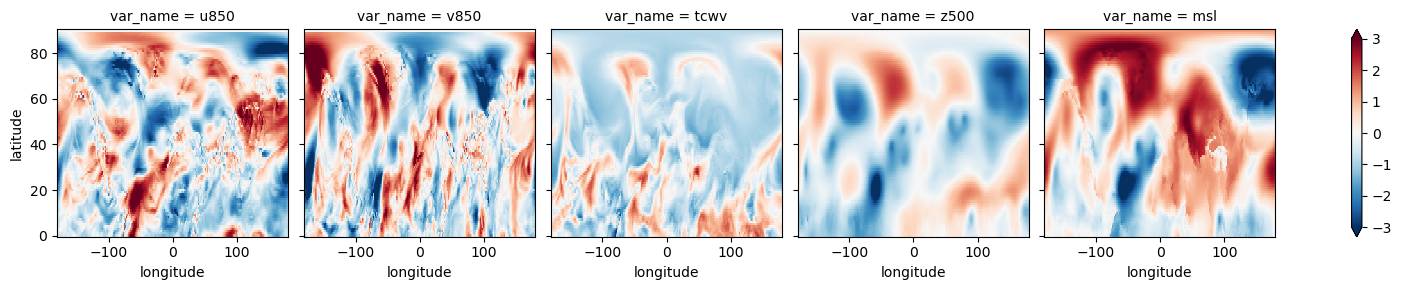

In [64]:
# ds_array = /
# ds_norm = (ds_array - ds_array.mean('time'))/ds_array.std('time')
ds_norm = ((ds - ds_mean)/ds_std).to_array('var_name').isel(time=-1000)
ds_norm.plot(col='var_name', vmax=3)
ds_norm

In [16]:
first_variable = True

variable = 'u'
level =850

sample_ds = open_sample_ds(all_days[0], variable, level)
R = build_regridder(sample_ds, target_grid=target_grid, method='bilinear')    


num_samples = all_days.size//256

### RERUN THiS FOR OTHER VAribaLES
for k in tqdm(range( num_samples, num_samples+1)):
    da_v = get_data_batch(256*k, 256*(k+1),'v', '850', R)
    da_tc = get_data_batch(256*k, 256*(k+1),'tcwv', 'surface', R)
    da_z = get_data_batch(256*k, 256*(k+1),'z', '500', R)
    da_msl = get_data_batch(256*k, 256*(k+1),'msl', 'surface', R)
    da_v = da_v.rename('v850').astype('float32') 
    da_tc = da_tc.rename('tcwv').astype('float32') 
    da_z = da_z.rename('z500').astype('float32') 
    da_msl = da_msl.rename('msl').astype('float32') 
    region = {'time': slice(256*k, 256*(k+1)),'latitude':slice(0,91), 'longitude':slice(0, 360)}
    # enc = {'z500': {"compressor":compressor}}
    enc = dict()
    da_v.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    da_tc.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    da_z.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    da_msl.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)
    # ds.to_array('var_name').mean('time').plot(col='var_name')

/tmp/ipykernel_3607308/827316853.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  src_nlat, src_nlon = s.dims['latitude'], s.dims['longitude']
/tmp/ipykernel_3607308/827316853.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tgt_nlat, tgt_nlon = target_grid.dims['latitude'], target_grid.dims['longitude']


  0%|          | 0/1 [00:00<?, ?it/s]

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronou

In [ ]:
region = {'time': slice(0, 256),'latitude':slice(0,91), 'longitude':slice(0, 360)}
enc = {'v850': {"compressors":compressor}}
da_v0.to_dataset().to_zarr(zarr_out, mode='a', region=region, encoding=enc)

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/core/group.py:2552: UserWarning: The `compressor` argument is deprecated. Use `compressors` instead.
  compressors = _parse_deprecated_compressor(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/zarr/api/asynchronous.py:228: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 63.99 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [18]:
ds.close()

In [24]:
ds.isel(time=-1)#.to_array('var_name').plot(col='var_name')

<xarray.Dataset> Size: 659kB
Dimensions:    (latitude: 91, longitude: 360)
Coordinates:
  * latitude   (latitude) float64 728B 90.0 89.0 88.0 87.0 ... 3.0 2.0 1.0 0.0
    time       datetime64[ns] 8B 2025-08-30
  * longitude  (longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
Data variables:
    u850       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    v850       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    msl        (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    tcwv       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>
    z500       (latitude, longitude) float32 131kB dask.array<chunksize=(91, 360), meta=np.ndarray>

In [27]:
ds = xr.open_zarr(zarr_out)

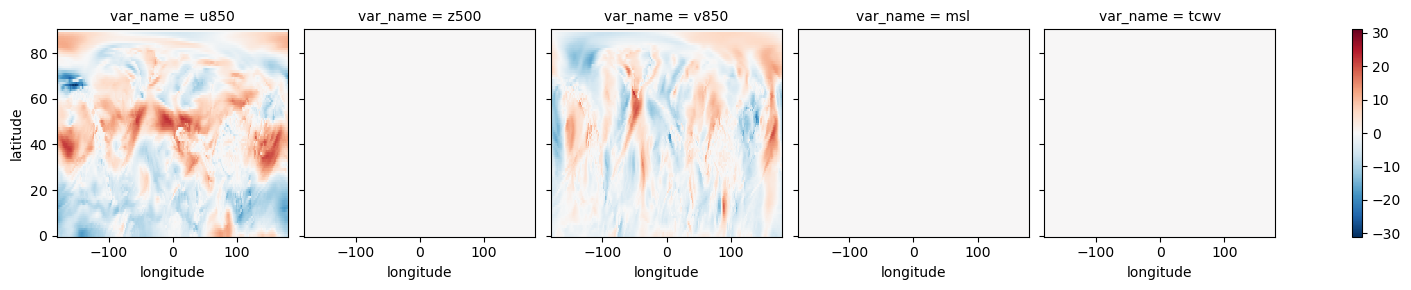

In [30]:
ds.isel(time=12394).to_array('var_name').plot(col='var_name')

In [ ]:

R = build_regridder(sample_ds, var_key=variable, level=level, target_grid=target_grid, method='bilinear')    
years = range(all_days[0].year, all_days[-1].year + 1)
first_year_for_this_var = True

y = years[0]


NameError: name 'all_days' is not defined

In [ ]:
write_variable_year(variable, level, y, R,
                    mode=('w' if first_variable and first_year_for_this_var else 'a'))

In [ ]:
first_variable = True
for variable, level in vars_levels:
    # Pick a sample day that exists (just take the first)
    sample_ds = open_sample_ds(all_days[0], variable, level)
    # Choose regridding method: bilinear safe for u/v/T/z/msl/tcwv
    R = build_regridder(sample_ds, var_key=variable, level=level, target_grid=target_grid, method='bilinear')    
    # Stream by year to keep graphs modest
    years = range(all_days[0].year, all_days[-1].year + 1)
    first_year_for_this_var = True
    for y in tqdm(years):
        write_variable_year(variable, level, y, R,
                            mode=('w' if first_variable and first_year_for_this_var else 'a'))
        first_year_for_this_var = False
    first_variable = False

# Consolidate metadata once
xr.backends.zarr.consolidate_metadata(zarr_out)

# -----------------------
# Optional: add normalized variables into the SAME store
#   data_normed = (X - mu) / sigma, where
#   mu = global mean over time
#   sigma = weighted std over lon, lat, time (weights = cos(lat))
# -----------------------
ds = xr.open_zarr(zarr_out, chunks=chunks)

# Compute grand mean per var
mu = ds.mean('time').compute()

# Weighted std across (lon, lat, time)
# broadcast weights over lon/time
w = np.cos(np.deg2rad(ds.lat)).astype('float32')
w = w / w.mean()  # optional normalization of weights
std = ( (ds - mu).weighted(w).std(dim=('lon','lat','time')) ).compute()

ds_norm = xr.Dataset(
    data_vars=dict(
        data_normed=((ds - mu) / std).astype('float32'),
        mean_value=mu.astype('float32'),
        std_value=std.astype('float32'),
    ),
    coords=dict(time=ds.time, lat=ds.lat, lon=ds.lon)
)

enc_norm = {
    "data_normed": {"compressor": compressor, "dtype": "float32"},
    "mean_value":  {"compressor": compressor, "dtype": "float32"},
    "std_value":   {"compressor": compressor, "dtype": "float32"},
    "lat": {"compressor": compressor}, "lon": {"compressor": compressor}, "time": {"compressor": compressor}
}

ds_norm.to_zarr(zarr_out, mode='a', encoding=enc_norm)
xr.backends.zarr.consolidate_metadata(zarr_out)

# -----------------------
# Reading hint (if you prefer -180..180 longitudes for training)
# -----------------------
# ds_train = xr.open_zarr(zarr_out)
# ds_train = ds_train.assign_coords(lon=((ds_train.lon + 180) % 360)).sortby('lon')

/tmp/ipykernel_3232622/3972593739.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  src_nlat, src_nlon = s.dims['lat'], s.dims['lon']
/tmp/ipykernel_3232622/3972593739.py:22: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  tgt_nlat, tgt_nlon = target_grid.dims['lat'], target_grid.dims['lon']
